In [69]:
import numpy as np
import matplotlib.pyplot as plt
import time, sys, os

sys.path.append(os.path.abspath("./src"))

# from minimization import mini
import minimization

mini = minimization.mini

from integrals_roots import integrals

plt.rcParams['figure.figsize'] = [6.0, 3.8]

## Minimization

Take the function

$$V(x) = \frac{x^{2}}{10} + \sin(x) + e^{-5x^{2}}$$

For many reasons, we might want to minimize this function. For example, it could
describe the cost from a predictive model (with one weight which is kind of silly),
or the energy of a sampling distribution (as it is used in the other notebook), in 
which case the minumum would be the mode.

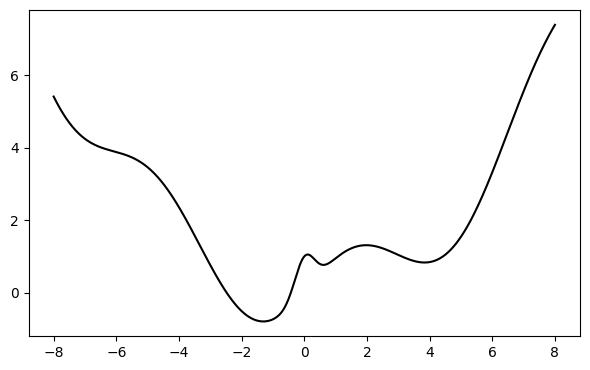

Z = 6.497698


In [45]:
v = lambda x: (
    (x**2 / 10) + (np.sin(x)) + (np.exp(-5*(x**2)))
)

z = integrals.midpoint_area(lambda x: np.exp(-v(x)), -10, 10, 20_000)

p = lambda x: (
    (1 / z) * (np.exp(-v(x)))
)

xs = np.linspace(-8, 8, 2_000)

plt.plot(xs, v(xs), color = "black")

plt.tight_layout()
plt.show()

print(f"Z = {z:.6f}")

### Gradient Descent

The simplist and most common technique for minimization is gradient descent. Fairly self
explanatory, if $\nabla f$ gives us the direction and magnitude of the greatest rate of 
change, we should at each step follow in the opposite direction, scaled by the gradient 
(so that we go faster on steeper slopes).

Iteratively, starting with some $x_0$, we find the next iteration as

$$x_{n + 1} = x_n - \alpha \nabla f(x_n)$$

Where $\alpha$ is our "learning rate," or step size, for the iteration; higher $\alpha$ 
means faster but (usually) less accurate minimizations.

In [46]:
start = time.perf_counter_ns()
x_star, v_star = mini.descent_1D(v, x_0 = 0, error = 0.0005, alpha = 0.1)
decent_time = time.perf_counter_ns() - start

print(f"x*      = {x_star:.6f}")
print(f"V(x*)   = {v_star:.6f}")
print(f"runtime: {(decent_time /1_000_000):.2f} ms")

x*      = -1.256836
V(x*)   = -0.792314
runtime: 0.47 ms


While this appears slower than a linear scan, the bellow implementation does the bulk of the 
work in the Numpy API (which is built in C, a much faster, lower-level language), so the fact
that they are even close shows the efficiency of the algorithm.

On top of that, for higher-dimensional systems, the linear scan scales exponentially, whereas
the gradient approach scales linearly (funnily enough).

In [47]:
grid = np.linspace(-10, 10, 200_001)
grid_v = v(grid)
start = time.perf_counter_ns()
grid_min = grid[grid_v.argmin()]
grid_time = time.perf_counter_ns() - start

print(f"grid minimum: x = {grid_min:.6f}, V = {grid_v.min():.6f}")
print(f"runtime: {(decent_time /1_000_000):.2f} ms")

grid minimum: x = -1.308600, V = -0.794388
runtime: 0.47 ms


The biggest limitation of gradient descent is that, by the nature of the algorithm, will
never budge when it finds a local minimum.

The algorithm finds the global max here only because we chose $x_0 = 0$ as the
nitial guess and the minimum happens to lie arround there. If we instead set 
$x_0 = 1$, this approach then breaks down.

In [66]:
x_star, v_star = mini.descent_1D(v, x_0 = 1, error = 0.0005, alpha = 0.1)

print(f"x*      = {x_star:.6f}")
print(f"V(x*)   = {v_star:.6f}")

x*      = 0.622031
V(x*)   = 0.766165


### Simulated annealing

Gradient descent walks downhill and stops at the first minimum it reaches, which for a $V$ like this one means stopping near wherever you happened to start. Annealing works to fix that by letting the walk go uphill sometimes, while making it less willing to do so as time goes on (such that it still converges). The name comes from blacksmithing: cool a metal slowly and its atoms have time to settle into a low energy lattice, quench it and they freeze wherever they were (this is also where "temperature" gets its name from below).

Starting from $x^{(1)} = 0$, propose a step $x' = x^{(k)} + \varepsilon$ with $\varepsilon \sim N(0, \alpha)$ (or some other distribution), and accept it with probability

$$\alpha = \min\left(1,\; e^{-\frac{V(x') - V(x^{(k)})}{T_{k}}}\right) $$

Where $T_{k}$ is the temperature of the $k^{th}$ sample, defined by some decreasing --- typically logarithmicaly --- function. In this implementation we use:

$$T_{k} = \frac{10}{\ln(k + 1)}$$

Downhill proposals make the exponent positive and are always taken. Uphill proposals are taken with a probability that depends on how steep the move is relative to the current temperature, so early on the walk wanders nearly freely and later it mostly refuses to climb.

In python, the implimentation looks something like this:

```python
def annealing(v, alpha, iterations):
    x = 0
    best = (x, v(x), 0)

    for k in range(iterations):
        proposed = x + (normal() * alpha)

        if random() < exp((v(x) - v(proposed)) / t(k)):
            if v(proposed) < best[1]:
                best = (proposed, v(proposed), k + 1)
            x = proposed

    return best
```

Bellow is an example of finding the min using the above temp and $\alpha = 0.5$

In [70]:
start = time.perf_counter_ns()

x_star, v_star, found_at = mini.annealing(v, max_iter = 5*10**4, alpha = 0.02)

annealing_time = (time.perf_counter_ns() - start) * 1e-6

print(f"x*      = {x_star:.6f}")
print(f"V(x*)   = {v_star:.6f}")
print(f"found at iteration {found_at} of 50,000")
print(f"runtime: {annealing_time:.2f} ms")

TypeError: Minimization.annealing() got an unexpected keyword argument 'max_iter'

One run does not say much about a randomized method, so here it is 200 more times:

x* between -1.3098 and -1.3070
landed within 0.05 of the grid minimum 100% of the time
median iteration where x* was found: 5476


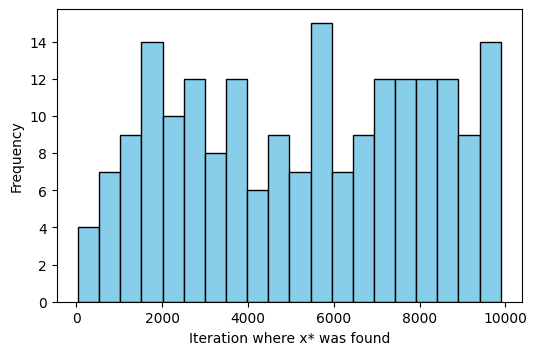

In [ ]:
restarts = [mini.annealing(v, iterations = 10**4) for _ in range(200)]

best = np.array([run[0] for run in restarts])
iteration = np.array([run[2] for run in restarts])

print(f"x* between {best.min():.4f} and {best.max():.4f}")
print(f"landed within 0.05 of the grid minimum {100 * np.mean(np.abs(best - grid_min) < 0.05):.0f}% of the time")
print(f"median iteration where x* was found: {int(np.median(iteration))}")

plt.hist(iteration, bins = 20, color = "skyblue", edgecolor = "black")
plt.xlabel("Iteration where x* was found")
plt.ylabel("Frequency")
plt.show()